## This notebook uses nvidia.build.com api keys to run inference on models remotely. (as opposed to local gpu inference)

In [73]:
import os                                                                                                            
os.environ["RAY_TMPDIR"] = "/raid/mwason/tmp"
os.environ["NVIDIA_API_KEY"] = "your-new-key"

In [2]:
import ray                                                                                                           
ray.init(include_dashboard=False)                                                                                    
                                                                                                            

2026-03-30 09:59:43,522	INFO worker.py:2013 -- Started a local Ray instance.
/raid/mwason/retriever/lib/python3.12/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.12.13
Ray version:,2.54.1


In [3]:
from nemo_retriever import create_ingestor                                                                           
from pathlib import Path 

In [4]:
documents = [str(Path("/home/nfs/mwason/nemo/NeMo-Retriever/data/multimodal_test.pdf"))]                             
ingestor = create_ingestor(run_mode="batch")
                                                                                                                   
ingestor = (                                                                                                       
ingestor.files(documents)
.extract(                                                                                                          
  page_elements_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-page-elements-v3",
  graphic_elements_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-graphic-elements-v1",               
  ocr_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemoretriever-ocr-v1",                                    
  table_structure_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-table-structure-v1"
)                                                                                                                  
.embed(                                                                                                          
  embed_invoke_url="https://integrate.api.nvidia.com/v1/embeddings",                                               
  model_name="nvidia/llama-nemotron-embed-1b-v2",                                                                  
  embed_modality="text",
)                                                                                                                  
.vdb_upload() 
)

2026-03-30 10:00:12,515	INFO worker.py:1831 -- Calling ray.init() again after it has already been called.


In [5]:
ray_dataset = ingestor.ingest()                                                                                      
chunks = ray_dataset.get_dataset().take_all()

2026-03-30 10:00:13,315	INFO logging.py:392 -- Registered dataset logger for dataset dataset_12_0
2026-03-30 10:00:13,330	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_12_0. Full logs are in /raid/mwason/tmp/ray/session_2026-03-30_09-59-29_921435_39847/logs/ray-data
2026-03-30 10:00:13,330	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_12_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadBinary] -> ActorPoolMapOperator[MapBatches(DocToPdfConversionActor)] -> TaskPoolMapOperator[MapBatches(PDFSplitActor)] -> TaskPoolMapOperator[MapBatches(PDFExtractionActor)] -> TaskPoolMapOperator[StreamingRepartition[num_rows_per_block=32]] -> ActorPoolMapOperator[MapBatches(PageElementDetectionActor)] -> ActorPoolMapOperator[MapBatches(GraphicElementsActor)] -> ActorPoolMapOperator[MapBatches(TableStructureActor)] -> ActorPoolMapOperator[MapBatches(OCRActor)] -> TaskPoolMapOperator[StreamingRepartition[num_rows_per_block=256]] -> ActorPoolMapOperator[

In [6]:
print(f"Total chunks: {len(chunks)}") 

Total chunks: 8


In [7]:
print(chunks[2].keys()) 

dict_keys(['path', 'page_number', 'source_id', 'text', 'page_image', 'images', 'tables', 'charts', 'infographics', 'metadata', 'page_elements_v3', 'page_elements_v3_num_detections', 'page_elements_v3_counts_by_label', 'chart', 'graphic_elements_ocr_v1', 'table', 'table_structure_ocr_v1', 'infographic', 'ocr_v1', '_content_type', 'text_embeddings_1b_v2', '_contains_embeddings', 'text_embeddings_1b_v2_dim', 'text_embeddings_1b_v2_has_embedding'])


In [8]:
from nemo_retriever.retriever import Retriever

In [9]:
retriever = Retriever(
lancedb_uri="lancedb",                                                                                             
lancedb_table="nv-ingest",
embedder="nvidia/llama-3.2-nv-embedqa-1b-v2",                                                                      
top_k=5,                                                                                                           
reranker=False                                                                                                     
)                                                                                                                    
              
query = "Given their activities, which animal is responsible for the typos in my documents?"                         
hits = retriever.query(query)
                                                                                                                   
for hit in hits:
  print(hit["text"])
  print("---")  

/raid/mwason/retriever/lib/python3.12/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

/raid/mwason/retriever/lib/python3.12/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


| lable 1 |
| This table describes some animals, and some activities they might be doing in specific |
| locations. |
| Animal | Activity | Place |
| Giraffe | Driving a car | At the beach |
| Lion | Putting on sunscreen | At the park |
| Cat | Jumping onto a laptop | In a home office |
| Dog | Chasing a squirrel | In the front yard |
| Chart 1 |
---
TestingDocument
A sample document with headings and placeholder text
Introduction
This is a placeholder document that can be used for any purpose. It contains some 
headings and some placeholder text to fill the space. The text is not important and contains 
no real value, but it is useful for testing. Below, we will have some simple tables and charts 
that we can use to confirm Ingest is working as expected.
Table 1
This table describes some animals, and some activities they might be doing in specific 
locations.
Animal Activity Place
Gira@e Driving a car At the beach
Lion Putting on sunscreen At the park
Cat Jumping onto a laptop In a ho

In [10]:
from openai import OpenAI                                                                                            
import os                                                                                                             

In [11]:
client = OpenAI(
base_url="https://integrate.api.nvidia.com/v1",
api_key=os.environ.get("NVIDIA_API_KEY")                                                                           
)                                                                                                                    
                                                                                                                   
hit_texts = [hit["text"] for hit in hits]                                                                            
# query = "Given their activities, which animal is responsible for the typos in my documents?"
query = "What is the total number of tables, charts, and bullet points in the document, and which page has the most content elements?"
prompt = f"""                                                                                                        
Given the following retrieved documents, answer the question: {query}
                                                                                                                   
Documents:      
{hit_texts}
"""

completion = client.chat.completions.create(
model="nvidia/nemotron-3-super-120b-a12b",
messages=[{"role": "user", "content": prompt}],                                                                    
stream=False
)                                                                                                                    
              
print(completion.choices[0].message.content) 

**Counts across the whole document**

- Tables: **4**  
- Charts: **3**  
- Bullet points: **3**  

**Page with the most content elements**

The third page (the string beginning with “Section One …”) contains the highest number of content elements:

- Tables: 1  
- Charts: 0  
- Bullet points: 3  

**Total on that page:** 1 + 0 + 3 = **4** elements, which is more than any other page.


In [12]:
print(hit_texts)

['| lable 1 |\n| This table describes some animals, and some activities they might be doing in specific |\n| locations. |\n| Animal | Activity | Place |\n| Giraffe | Driving a car | At the beach |\n| Lion | Putting on sunscreen | At the park |\n| Cat | Jumping onto a laptop | In a home office |\n| Dog | Chasing a squirrel | In the front yard |\n| Chart 1 |', 'TestingDocument\r\nA sample document with headings and placeholder text\r\nIntroduction\r\nThis is a placeholder document that can be used for any purpose. It contains some \r\nheadings and some placeholder text to fill the space. The text is not important and contains \r\nno real value, but it is useful for testing. Below, we will have some simple tables and charts \r\nthat we can use to confirm Ingest is working as expected.\r\nTable 1\r\nThis table describes some animals, and some activities they might be doing in specific \r\nlocations.\r\nAnimal Activity Place\r\nGira@e Driving a car At the beach\r\nLion Putting on sunscreen 

# lancedb exploration

In [13]:
import lancedb

In [14]:
db = lancedb.connect("lancedb")
table = db.open_table("nv-ingest")

In [15]:
print(table.schema)

vector: fixed_size_list<item: float>[2048]
  child 0, item: float
pdf_page: string
filename: string
pdf_basename: string
page_number: int32
source: string
source_id: string
path: string
text: string
metadata: string


In [16]:
df = table.to_pandas()
print(df.columns)
print(df.head())

Index(['vector', 'pdf_page', 'filename', 'pdf_basename', 'page_number',
       'source', 'source_id', 'path', 'text', 'metadata'],
      dtype='object')
                                              vector           pdf_page  \
0  [-0.0009279251, -0.005710602, 0.034454346, 0.0...  multimodal_test_1   
1  [-0.0062065125, 0.035064697, 0.040740967, -0.0...  multimodal_test_1   
2  [0.013954163, 0.01689148, 0.026306152, 0.02578...  multimodal_test_1   
3  [-0.013458252, 0.0067749023, 0.023620605, 0.01...  multimodal_test_2   
4  [0.0023021698, 0.010917664, 0.0289917, 0.01829...  multimodal_test_2   

              filename     pdf_basename  page_number  \
0  multimodal_test.pdf  multimodal_test            1   
1  multimodal_test.pdf  multimodal_test            1   
2  multimodal_test.pdf  multimodal_test            1   
3  multimodal_test.pdf  multimodal_test            2   
4  multimodal_test.pdf  multimodal_test            2   

                                              source  \
0  

In [17]:
for i, row in df.iterrows():
    print(f"--- Chunk {i} ---")
    print("Text:", row["text"][:100])
    print("Page:", row["page_number"])
    print("Source:", row["source"])
    print("Vector dim:", len(row["vector"]))

--- Chunk 0 ---
Text: TestingDocument
A sample document with headings and placeholder text
Introduction
This is a place
Page: 1
Source: {"source_id": "/home/nfs/mwason/nemo/NeMo-Retriever/data/multimodal_test.pdf"}
Vector dim: 2048
--- Chunk 1 ---
Text: | lable 1 |
| This table describes some animals, and some activities they might be doing in specific
Page: 1
Source: {"source_id": "/home/nfs/mwason/nemo/NeMo-Retriever/data/multimodal_test.pdf"}
Vector dim: 2048
--- Chunk 2 ---
Text: Chart 1 This chart shows some gadgets, and some very fictitious costs. Gadgets and their cost $160.0
Page: 1
Source: {"source_id": "/home/nfs/mwason/nemo/NeMo-Retriever/data/multimodal_test.pdf"}
Vector dim: 2048
--- Chunk 3 ---
Text: Section One
This is the first section of the document. It has some more placeholder text to show ho
Page: 2
Source: {"source_id": "/home/nfs/mwason/nemo/NeMo-Retriever/data/multimodal_test.pdf"}
Vector dim: 2048
--- Chunk 4 ---
Text: | smoke test to ensure extraction is worki

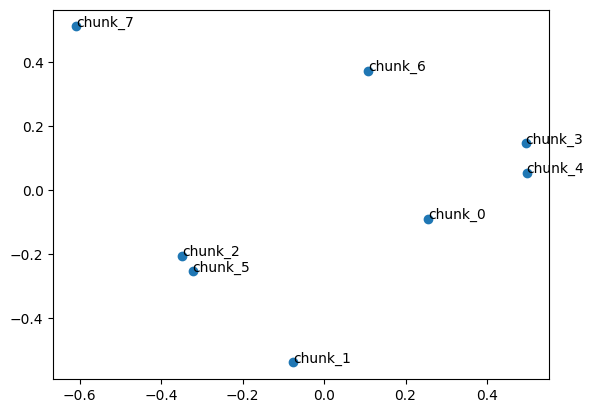

In [18]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

vectors = np.stack(df["vector"].values)
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.scatter(reduced[:, 0], reduced[:, 1])
for i, row in df.iterrows():
    plt.annotate(f"chunk_{i}", reduced[i])
plt.show()

In [19]:
    for i, chunk in enumerate(chunks):
        print(f"--- Chunk {i} ---")
        print(chunk["text"])                                                                                           
        print()   

--- Chunk 0 ---
TestingDocument
A sample document with headings and placeholder text
Introduction
This is a placeholder document that can be used for any purpose. It contains some 
headings and some placeholder text to fill the space. The text is not important and contains 
no real value, but it is useful for testing. Below, we will have some simple tables and charts 
that we can use to confirm Ingest is working as expected.
Table 1
This table describes some animals, and some activities they might be doing in specific 
locations.
Animal Activity Place
Gira@e Driving a car At the beach
Lion Putting on sunscreen At the park
Cat Jumping onto a laptop In a home o@ice
Dog Chasing a squirrel In the front yard
Chart 1
This chart shows some gadgets, and some very fictitious costs.

--- Chunk 1 ---
| lable 1 |
| This table describes some animals, and some activities they might be doing in specific |
| locations. |
| Animal | Activity | Place |
| Giraffe | Driving a car | At the beach |
| Lion |

## ReAct Loop

In [20]:
import json
import os
from openai import OpenAI

In [43]:
AGENT_MODEL = "meta/llama-3.1-70b-instruct"
MAX_ITERATIONS = 8

In [44]:
  client = OpenAI(                                          
      base_url="https://integrate.api.nvidia.com/v1",
      api_key=os.environ.get("NVIDIA_API_KEY")                                                                         
  )

### Tools functions

In [45]:
 def run_query_docs(query_string: str) -> list[dict]:                                                              
     hits = retriever.query(query_string)                                                                          
     # Drop vector field to avoid context bloat (~40KB per query)                                                  
     return [                                                                                                      
         {"text": h.get("text", ""), "source": h.get("pdf_basename", ""), "page": h.get("page_number", "")}        
         for h in hits
     ]

 def run_ingest_pdf(pdf_path: str) -> str:
     pipeline = (
         create_ingestor(run_mode="batch")
         .files([pdf_path])
         .extract(
             page_elements_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-page-elements-v3",
             graphic_elements_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-graphic-elements-v1",
             ocr_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemoretriever-ocr-v1",
             table_structure_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-table-structure-v1"
         )
         .embed(
             embed_invoke_url="https://integrate.api.nvidia.com/v1/embeddings",
             model_name="nvidia/llama-nemotron-embed-1b-v2",
             embed_modality="text",
         )
         .vdb_upload()
     )
     pipeline.ingest()
     return f"Ingested {pdf_path} successfully."

In [46]:
TOOLS = [
  {
    "type": "function",
    "function": {
      "name": "query_docs",
      "description": "Search the document knowledge base for relevant text chunks. Call multiple times with different queries to gather more context.",
      "parameters": {
        "type": "object",
        "properties": {
          "query_string": {
            "type": "string",
            "description": "Search query to run against the vector database."
          }
        },
        "required": ["query_string"]
      }
    }
  },
  {
    "type": "function",
    "function": {
      "name": "ingest_pdf",
      "description": "Ingest a PDF file into the knowledge base. Use only when the user provides a new PDF path.",
      "parameters": {
        "type": "object",
        "properties": {
          "pdf_path": {
            "type": "string",
            "description": "Filesystem path to the PDF."
          }
        },
        "required": ["pdf_path"]
      }
    }
  },
  {
    "type": "function",
    "function": {
      "name": "final_answer",
      "description": "Provide the final answer when confident. Terminates the loop.",
      "parameters": {
        "type": "object",
        "properties": {
          "answer": {
            "type": "string",
            "description": "The complete answer to return."
          }
        },
        "required": ["answer"]
      }
    }
  }
]

In [47]:
 SYSTEM_PROMPT = """You are a research assistant with access to a document knowledge base.
 Reason step by step and search the knowledge base as needed using query_docs.
 Search multiple times with different queries if needed to gather enough information.
 When confident, call final_answer. Do not make up information."""

### ReAct loop

In [48]:
 def react_agent(question: str, verbose: bool = True) -> str:                                                      
     messages = [                                                                                                  
         {"role": "system", "content": SYSTEM_PROMPT},                                                             
         {"role": "user", "content": question},                                                                    
     ]                                                                                                             
                                                                                                                   
     for iteration in range(1, MAX_ITERATIONS + 1):                                                                
         if verbose:                                                                                               
             print(f"\n[Iteration {iteration}]")                                                                   
                                                                                                                   
         response = client.chat.completions.create(                                                                
             model=AGENT_MODEL,                                                                                    
             messages=messages,                                                                                    
             tools=TOOLS,                                                                                          
             tool_choice="auto",
             parallel_tool_calls=False
         )

         msg = response.choices[0].message
         finish_reason = response.choices[0].finish_reason

         if verbose:
             print(f"  finish_reason: {finish_reason}")

         # Append assistant message to history
         messages.append(msg)

         # No tool calls — model answered directly
         if finish_reason == "stop" or not msg.tool_calls:
             return msg.content or "(No answer produced)"

         # Process tool calls
         for tool_call in msg.tool_calls:
             fn_name = tool_call.function.name
             fn_args = json.loads(tool_call.function.arguments)

             if verbose:
                 print(f"  -> {fn_name}({json.dumps(fn_args)})")

             if fn_name == "final_answer":
                 answer = fn_args["answer"]
                 if verbose:
                     print(f"\n[Final Answer]\n{answer}")
                 return answer
             elif fn_name == "query_docs":
                 result = json.dumps(run_query_docs(fn_args["query_string"]), ensure_ascii=False)
             elif fn_name == "ingest_pdf":
                 result = run_ingest_pdf(fn_args["pdf_path"])
             else:
                 result = f"Unknown tool: {fn_name}"

             if verbose:
                 print(f"     result: {result[:200]}...")

             # Feed tool result back as a tool message
             messages.append({
                 "role": "tool",
                 "tool_call_id": tool_call.id,
                 "content": result,
             })

     return f"[Agent stopped after {MAX_ITERATIONS} iterations without a final answer]"



In [49]:
 answer = react_agent(
     "What is the total number of tables, charts, and bullet points in the document, and which page has the most content elements?",
     verbose=True,
 )
 print("\n=== ANSWER ===")
 print(answer)


[Iteration 1]


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 answer = react_agent(                                                                        │
│   2 │   "What is the total number of tables, charts, and bullet points in the document, and      │
│   3 │   verbose=True,                                                                            │
│   4 )                                                                                            │
│                                                                                                  │
│ in react_agent:11                                                                                │
│                                                                                                  │
│    8 │   │   if verbose:                                                                         │
│    9 │   │   │   print(f"\n[Iteration {iteration}]")                                             │
│   10 │   │                                                                                       │
│ ❱ 11 │   │   response = client.chat.completions.create(                                          │
│   12 │   │   │   model=AGENT_MODEL,                                                              │
│   13 │   │   │   messages=messages,                                                              │
│   14 │   │   │   tools=TOOLS,                                                                    │
│                                                                                                  │
│ /raid/mwason/retriever/lib/python3.12/site-packages/openai/_utils/_utils.py:286 in wrapper       │
│                                                                                                  │
│   283 │   │   │   │   │   else:                                                                  │
│   284 │   │   │   │   │   │   msg = f"Missing required argument: {quote(missing[0])}"            │
│   285 │   │   │   │   raise TypeError(msg)                                                       │
│ ❱ 286 │   │   │   return func(*args, **kwargs)                                                   │
│   287 │   │                                                                                      │
│   288 │   │   return wrapper  # type: ignore                                                     │
│   289                                                                                            │
│                                                                                                  │
│ /raid/mwason/retriever/lib/python3.12/site-packages/openai/resources/chat/completions/completion │
│ s.py:1211 in create                                                                              │
│                                                                                                  │
│   1208 │   │   timeout: float | httpx.Timeout | None | NotGiven = not_given,                     │
│   1209 │   ) -> ChatCompletion | Stream[ChatCompletionChunk]:                                    │
│   1210 │   │   validate_response_format(response_format)                                         │
│ ❱ 1211 │   │   return self._post(                                                                │
│   1212 │   │   │   "/chat/completions",                                                          │
│   1213 │   │   │   body=maybe_transform(                                                         │
│   1214 │   │   │   │   {                                                                         │
│                                                                                                  │
│ /raid/mwason/retriever/lib/python3.12/site-packages/openai/